In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "async-geotiff>=0.4",
#     "lonboard>=0.15.0",
#     "numpy>=2",
#     "obstore>=0.9.2",
#     "pillow>=12.1.1",
#     "sidecar>=0.8.1",
# ]
# ///

# Land Cover Cloud-Optimized GeoTIFF in Lonboard

Lonboard now has the ability to render arbitrary [Cloud-Optimized GeoTIFF] images. This example notebook will go through the process of visualizing a 1.5GB [NLCD Land Cover](https://www.mrlc.gov/data/type/land-cover) COG in Lonboard.

[Cloud-Optimized GeoTIFF]: https://cogeo.org/

## Dependencies

Install [`uv`](https://docs.astral.sh/uv) and then launch this notebook with:

```
uvx juv run examples/raster-cog-nlcd-server.ipynb
```

(The `uvx` command is included when installing `uv`).


## Imports

First our imports. We'll use [Obstore] for accessing S3 and [Async-GeoTIFF] for efficient reading of GeoTIFF files. We use [pillow] (imported as `PIL`) for encoding image tiles to PNG.

[Obstore]: https://developmentseed.org/obstore/latest/
[Async-GeoTIFF]: https://developmentseed.org/async-geotiff/latest/
[pillow]: https://pillow.readthedocs.io/en/stable/

In [2]:
import io

import numpy as np
from async_geotiff import GeoTIFF, Tile
from obstore.store import S3Store
from PIL import Image
from sidecar import Sidecar

from lonboard import Map, RasterLayer
from lonboard.raster import EncodedImage

## Access GeoTIFF from AWS S3 bucket with Obstore and Async-GeoTIFF

First, we create an Obstore [`S3Store`] mounted to the bucket of interest. Then we open a [`GeoTIFF`] from a path within that bucket.

[`S3Store`]: https://developmentseed.org/obstore/latest/api/store/aws/#obstore.store.S3Store
[`GeoTIFF`]: https://developmentseed.org/async-geotiff/latest/api/geotiff/#geotiff

In [3]:
# Obstore store
store = S3Store(
    bucket="ds-deck.gl-raster-public",
    region="us-east-1",
    skip_signature=True,
)

In [4]:
# Open our GeoTIFF instance
cog_path = "cog/Annual_NLCD_LndCov_2024_CU_C1V1.tif"
geotiff = await GeoTIFF.open(cog_path, store=store)

## Create Render Callback

Lonboard's COG support works by asynchronously fetching COG image tiles _through Python_ and then transferring the tile to JavaScript for visualization.

In this initial version of our support, we require the user to create a "render callback" function that transforms the loaded COG tile to a PNG-formatted RGB image.

The benefit of this approach is that you can use _any Python code_ to perform the rendering characteristics you desire.

In [5]:
# Access the colormap as a numpy RGB array
cmap_array = geotiff.colormap.as_array()


def render_paletted_tile(tile: Tile) -> EncodedImage:
    # data is (1, height, width), uint8 — single band with palette indices
    arr = tile.array.data[0]  # shape: (H, W)

    # Add alpha channel: fully transparent (0) where nodata, opaque (255) elsewhere
    alpha = np.full(arr.shape, 255, dtype=np.uint8)
    if tile.array.nodata is not None:
        alpha[arr == tile.array.nodata] = 0

    # Map palette indices to RGBA
    rgba = np.empty((*arr.shape, 4), dtype=np.uint8)
    rgba[..., :3] = cmap_array[arr]  # (H, W, 3)
    rgba[..., 3] = alpha  # (H, W)

    # Serialize to PNG
    img = Image.fromarray(rgba, mode="RGBA")
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return EncodedImage(data=buf.getvalue(), media_type="image/png")

Now, pass the `geotiff` instance and our "render callback" into the `from_geotiff` constructor:

In [6]:
layer = RasterLayer.from_geotiff(geotiff, render_tile=render_paletted_tile)

Now we can create a map and display it just like any other layer

In [7]:
# In JupyterLab, split the screen to render the map on the right
sidecar = Sidecar(anchor="split-right")

In [8]:
# Create the map
m = Map(layer, height=800)

In [9]:
# Render the map in the split screen
with sidecar:
    display(m)

## Debugging the render callback

We can debug our `render_paletted_tile` function by passing in a `tile` we fetch ourselves:

In [10]:
# Fetch a tile in the middle of the raster
num_tiles_x, num_tiles_y = geotiff.tile_count
midpoint_tile_x = num_tiles_x // 2
midpoint_tile_y = num_tiles_y // 2
tile = await geotiff.fetch_tile(midpoint_tile_x, midpoint_tile_y)

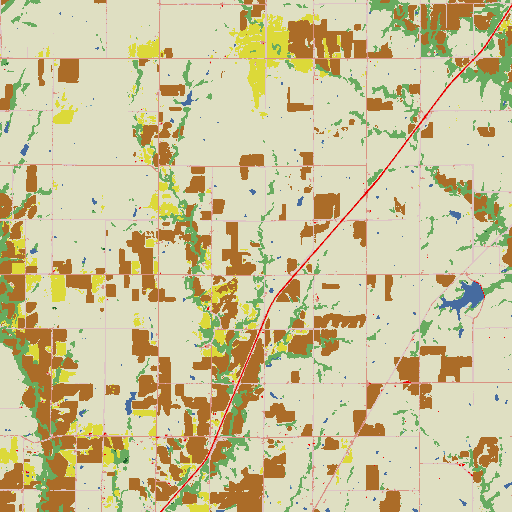

In [11]:
render_paletted_tile(tile)